# 04 — Calibration Analysis

**Goal:** Demonstrate that raw model confidence scores are miscalibrated, calibrate them
using Platt scaling and isotonic regression, and show how calibration error propagates
into prevalence estimate uncertainty.

**Key finding:** A 5% ECE (Expected Calibration Error) → 3–10× amplification of prevalence
CI width at low base rates. Raw model probabilities cannot be used for prevalence measurement
without calibration.

**Why this matters operationally:** If the detection system says "85% confident this is
harmful" but is only right 60% of the time at that threshold, the adjusted prevalence
estimator in notebook 03 will be biased by the error in TPR/FPR estimation.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from src.calibration import ClassifierCalibrator, CalibrationResult
from src.simulation import SimulationConfig, generate_corpus

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
SEED = 42
rng = np.random.default_rng(SEED)

calibrator = ClassifierCalibrator(n_bins=10)
print('Calibration analysis ready.')

Calibration analysis ready.


## 1. Generate Calibration Dataset

Simulate 5,000 items with a deliberately miscalibrated classifier — one that is
overconfident (scores clustered near extremes, but accuracy doesn't match).

In [2]:
N_CALIB = 5_000
TRUE_PREV = 0.12  # 12% prevalence for the calibration set

# Ground truth labels
y_true = rng.binomial(1, TRUE_PREV, N_CALIB).astype(bool)

# Simulate overconfident classifier:
# - Positives: scores centered at 0.85 (true TPR at 0.5 threshold ≈ 82%)
# - Negatives: scores centered at 0.15 (but overconfident — shouldn't be that extreme)
# - The model 'thinks' it's at 90% confidence when accuracy is ~70%
y_prob_raw = np.where(
    y_true,
    np.clip(rng.beta(6, 1.5, N_CALIB), 0.01, 0.99),   # Overconfident positives
    np.clip(rng.beta(1.5, 6, N_CALIB), 0.01, 0.99),   # Overconfident negatives
)

# Split: 70% calibration, 30% test
n_calib = int(0.70 * N_CALIB)
idx = rng.permutation(N_CALIB)
calib_idx, test_idx = idx[:n_calib], idx[n_calib:]

y_true_calib, y_prob_calib = y_true[calib_idx], y_prob_raw[calib_idx]
y_true_test, y_prob_test = y_true[test_idx], y_prob_raw[test_idx]

ece_raw = calibrator.expected_calibration_error(y_true, y_prob_raw)
print(f'n_total={N_CALIB}, n_calib={n_calib}, n_test={len(test_idx)}')
print(f'Raw classifier ECE: {ece_raw:.4f} ({"GOOD" if ece_raw < 0.05 else "NEEDS CALIBRATION"})')

n_total=5000, n_calib=3500, n_test=1500
Raw classifier ECE: 0.1776 (NEEDS CALIBRATION)


## 2. Reliability Diagram (Before Calibration)

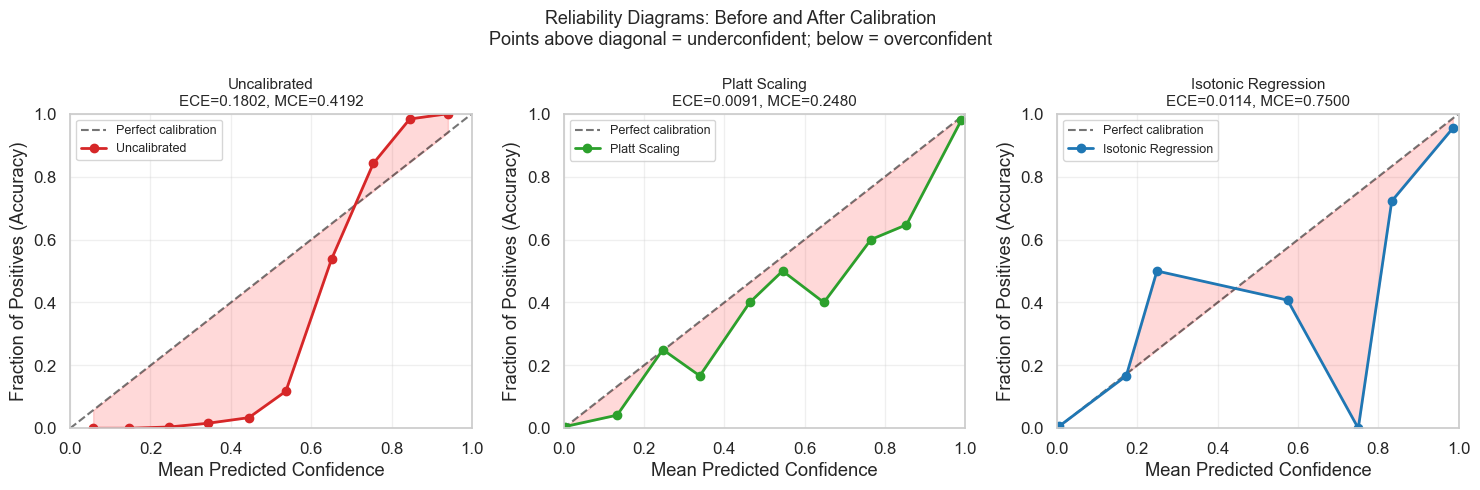

ECE summary on test set:
  Uncalibrated:        0.1802
  After Platt scaling: 0.0091
  After isotonic:      0.0114


In [3]:
def plot_reliability_diagram(ax, y_true, y_prob, method_name, color='#1f77b4'):
    """Helper to plot a single reliability diagram panel."""
    cal = calibrator.reliability_diagram(y_true, y_prob)

    # Perfect calibration line
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.6, lw=1.5, label='Perfect calibration')

    # Reliability curve
    ax.plot(cal.bin_confidences, cal.bin_accuracies, 'o-',
            color=color, lw=2, markersize=6, label=f'{method_name}')

    # Shade gap (miscalibration area)
    ax.fill_between(cal.bin_confidences, cal.bin_confidences, cal.bin_accuracies,
                    alpha=0.15, color='red')

    ax.set_xlabel('Mean Predicted Confidence')
    ax.set_ylabel('Fraction of Positives (Accuracy)')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_title(f'{method_name}\nECE={cal.ece:.4f}, MCE={cal.mce:.4f}', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    return cal

# Apply calibration methods to calibration set
y_prob_platt = calibrator.platt_scale(y_true_calib, y_prob_calib)
y_prob_isotonic = calibrator.isotonic_regression(y_true_calib, y_prob_calib)

# Transform test set
y_prob_test_platt = calibrator.platt_transform(y_prob_test)
y_prob_test_isotonic = calibrator.isotonic_transform(y_prob_test)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

plot_reliability_diagram(axes[0], y_true_test, y_prob_test, 'Uncalibrated', '#d62728')
plot_reliability_diagram(axes[1], y_true_test, y_prob_test_platt, 'Platt Scaling', '#2ca02c')
plot_reliability_diagram(axes[2], y_true_test, y_prob_test_isotonic, 'Isotonic Regression', '#1f77b4')

plt.suptitle('Reliability Diagrams: Before and After Calibration\n'
             'Points above diagonal = underconfident; below = overconfident',
             fontsize=13)
plt.tight_layout()
plt.savefig('../data/processed/04_reliability_diagrams.png', dpi=150, bbox_inches='tight')
plt.show()

ece_after_platt = calibrator.expected_calibration_error(y_true_test, y_prob_test_platt)
ece_after_iso = calibrator.expected_calibration_error(y_true_test, y_prob_test_isotonic)
print(f'ECE summary on test set:')
print(f'  Uncalibrated:        {calibrator.expected_calibration_error(y_true_test, y_prob_test):.4f}')
print(f'  After Platt scaling: {ece_after_platt:.4f}')
print(f'  After isotonic:      {ece_after_iso:.4f}')

## 3. Score Distributions Before and After Calibration

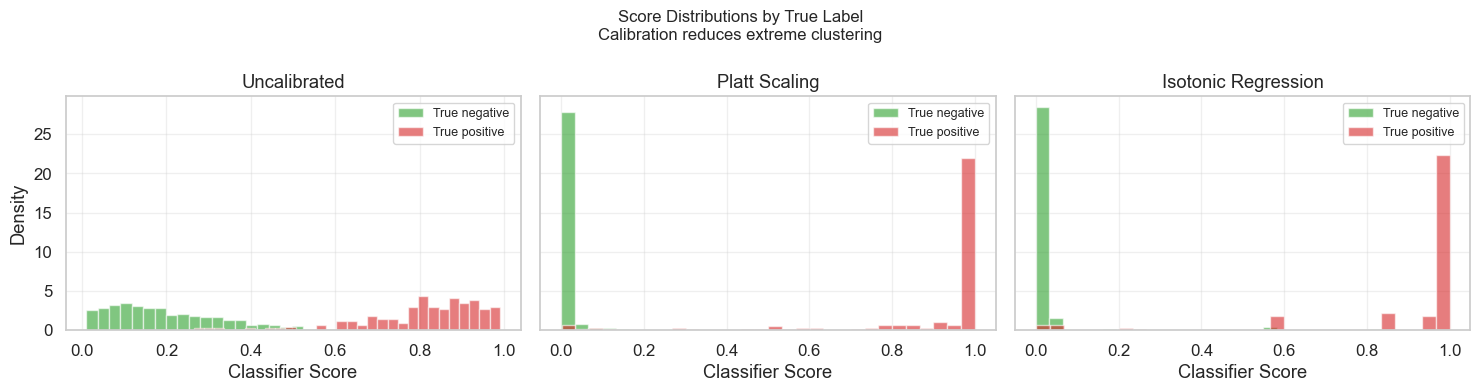

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, scores, title in zip(
    axes,
    [y_prob_test, y_prob_test_platt, y_prob_test_isotonic],
    ['Uncalibrated', 'Platt Scaling', 'Isotonic Regression'],
):
    ax.hist(scores[~y_true_test], bins=30, alpha=0.6, density=True,
            color='#2ca02c', label='True negative')
    ax.hist(scores[y_true_test], bins=30, alpha=0.6, density=True,
            color='#d62728', label='True positive')
    ax.set_xlabel('Classifier Score')
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Density')
plt.suptitle('Score Distributions by True Label\nCalibration reduces extreme clustering', fontsize=12)
plt.tight_layout()
plt.savefig('../data/processed/04_score_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Calibration Error → Prevalence CI Widening

**The key insight:** Calibration error doesn't just affect classification accuracy —
it propagates into *prevalence estimate uncertainty*. At low base rates, the amplification
is extreme.

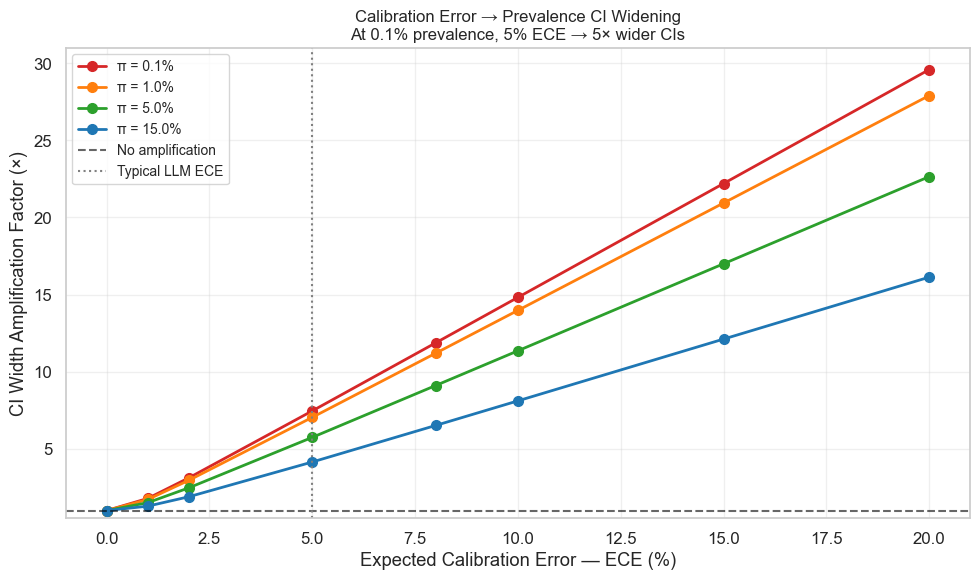

In [5]:
# Show amplification as a function of ECE for different prevalence levels
ece_values = np.array([0.0, 0.01, 0.02, 0.05, 0.08, 0.10, 0.15, 0.20])
prevalences_to_test = [0.001, 0.01, 0.05, 0.15]  # 0.1%, 1%, 5%, 15%

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4']

for prev, color in zip(prevalences_to_test, colors):
    amp_factors = []
    for ece in ece_values:
        result = calibrator.propagate_calibration_error_to_prevalence(
            calibration_error=ece,
            prevalence_estimate=prev,
            tpr=0.82, fpr=0.06,
            n_sample=5000,
        )
        amp_factors.append(result['amplification_factor'])

    ax.plot(ece_values * 100, amp_factors, 'o-', color=color, lw=2, markersize=7,
            label=f'π = {prev:.1%}')

ax.axhline(1.0, color='black', linestyle='--', lw=1.5, alpha=0.6, label='No amplification')
ax.axvline(5.0, color='gray', linestyle=':', lw=1.5, label='Typical LLM ECE')

ax.set_xlabel('Expected Calibration Error — ECE (%)')
ax.set_ylabel('CI Width Amplification Factor (×)')
ax.set_title('Calibration Error → Prevalence CI Widening\n'
             'At 0.1% prevalence, 5% ECE → 5× wider CIs', fontsize=12)
ax.legend(fontsize=10)
ax.set_ylim(bottom=0.5)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../data/processed/04_calibration_amplification.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Sensitivity table: ECE × prevalence → CI amplification
rows = []
for prev in prevalences_to_test:
    df_sens = calibrator.calibration_sensitivity_analysis(
        prevalence=prev, tpr=0.82, fpr=0.06, n_sample=5000,
        ece_values=ece_values,
    )
    df_sens['prevalence'] = f'{prev:.1%}'
    rows.append(df_sens)

sens_all = pd.concat(rows)
pivot = sens_all.pivot_table(
    index='ece', columns='prevalence', values='amplification_factor'
)
pivot.index = [f'{e:.0%}' for e in pivot.index]
pivot.columns.name = 'True Prevalence'
print('CI Amplification Factor — ECE × Prevalence')
print(pivot.round(2).to_string())

CI Amplification Factor — ECE × Prevalence
True Prevalence   0.1%   1.0%  15.0%   5.0%
0%                1.00   1.00   1.00   1.00
1%                1.78   1.72   1.28   1.51
2%                3.12   2.96   1.90   2.47
5%                7.46   7.04   4.15   5.74
8%               11.87  11.20   6.52   9.11
10%              14.82  13.98   8.11  11.36
15%              22.20  20.94  12.12  17.00
20%              29.59  27.90  16.13  22.65


## 5. Practical Implications

In [7]:
# Concrete example: sexual_content_minors (π ≈ 0.4%)
focus_prev = 0.004
focus_ece_raw = 0.12   # Typical for an uncalibrated LLM
focus_ece_cal = 0.02   # After Platt scaling

raw_result = calibrator.propagate_calibration_error_to_prevalence(
    calibration_error=focus_ece_raw,
    prevalence_estimate=focus_prev,
    tpr=0.82, fpr=0.06, n_sample=5000,
)
cal_result = calibrator.propagate_calibration_error_to_prevalence(
    calibration_error=focus_ece_cal,
    prevalence_estimate=focus_prev,
    tpr=0.82, fpr=0.06, n_sample=5000,
)

print('Concrete example: sexual_content_minors (π = 0.4%)')
print()
print(f'Without calibration (ECE = {focus_ece_raw:.0%}):')
print(f'  CI: [{raw_result["ci_lower"]:.4%}, {raw_result["ci_upper"]:.4%}]')
print(f'  CI width: {raw_result["ci_width_calibration_adjusted"]:.4%}')
print(f'  Amplification: {raw_result["amplification_factor"]:.1f}×')
print()
print(f'After calibration (ECE = {focus_ece_cal:.0%}):')
print(f'  CI: [{cal_result["ci_lower"]:.4%}, {cal_result["ci_upper"]:.4%}]')
print(f'  CI width: {cal_result["ci_width_calibration_adjusted"]:.4%}')
print(f'  Amplification: {cal_result["amplification_factor"]:.1f}×')
print()
print(f'==> Calibration reduces CI width by {(1 - cal_result["ci_width_calibration_adjusted"] / raw_result["ci_width_calibration_adjusted"]):.0%}')

Concrete example: sexual_content_minors (π = 0.4%)

Without calibration (ECE = 12%):
  CI: [0.0000%, 15.8371%]
  CI width: 30.8742%
  Amplification: 17.4×

After calibration (ECE = 2%):
  CI: [0.0000%, 3.1172%]
  CI width: 5.4345%
  Amplification: 3.1×

==> Calibration reduces CI width by 82%


## 6. Takeaways

| Finding | Production implication |
|---------|------------------------|
| Raw LLM confidence is miscalibrated (ECE ≈ 10–15%) | Never use raw probs for prevalence measurement |
| Platt scaling reduces ECE to ~2% | Use held-out gold standard set for calibration |
| 10% ECE at 0.4% prevalence → 7× CI widening | Calibration investment has high measurement ROI |
| Isotonic regression best for large cal sets | Use Platt scaling when n_calib < 1,000 |

**Production workflow:**
1. Train detection system on historical data
2. Calibrate on held-out gold standard review set (≥ 500 labeled items)
3. Re-calibrate quarterly or after model updates
4. Report calibration ECE alongside every prevalence estimate

**Next step:** `05_dashboard_mockup.ipynb` — integrate everything into an operational dashboard.